# Saga 5 — Análisis de Política y Escenarios

**Pregunta rectora:** ¿Qué estrategia es más robusta bajo futuros radicalmente distintos?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mise_utils import dynamics, viz, saga
viz.apply_mise_style()

state = saga.load_state('saga')

  Estado cargado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl (4 capas: ['red_fisica', 'red_social', 'identidad', 'dinamica'])


## 5.1 Intervenciones de política

Tres palancas principales: Cargo por Confiabilidad (CxC), incentivos FNCER, impuesto al carbono.

**Cada palanca modifica un lazo de retroalimentación distinto del sistema — no son aditivas, son interactivas**

In [2]:
print("Parámetros Base:")
print(dynamics.PARAMS_COLOMBIA_BASE)
print("\nParámetros con CxC y FNCER (Ejemplo):")
params_cxc = dynamics.PARAMS_COLOMBIA_BASE.copy()
params_cxc['precio_cxc'] = 18.0
print(params_cxc)

Parámetros Base:
{'capacidad_inicial': 14000, 'pipeline_inicial': 2000, 'demanda_inicial': 9500, 'tasa_crecimiento_demanda': 0.025, 'vida_util': 30, 'delay_construccion': 4, 'precio_base': 150, 'k_precio': 5.0, 'precio_techo': 600, 'sensibilidad_inversion': 50, 'precio_umbral_inversion': 180, 'inversion_maxima': 1500}

Parámetros con CxC y FNCER (Ejemplo):
{'capacidad_inicial': 14000, 'pipeline_inicial': 2000, 'demanda_inicial': 9500, 'tasa_crecimiento_demanda': 0.025, 'vida_util': 30, 'delay_construccion': 4, 'precio_base': 150, 'k_precio': 5.0, 'precio_techo': 600, 'sensibilidad_inversion': 50, 'precio_umbral_inversion': 180, 'inversion_maxima': 1500, 'precio_cxc': 18.0}


## 5.2 Los 4 escenarios

**Los escenarios no son predicciones — son futuros plausibles diseñados para estresar las estrategias. Si una estrategia funciona bien en los 4, es robusta**

In [3]:
print(dynamics.ESCENARIOS_COLOMBIA.keys())
escenarios_df = pd.DataFrame(dynamics.ESCENARIOS_COLOMBIA).T
display(escenarios_df)

dict_keys(['BAU', 'Gas Shock', 'Solar Revolution', 'Niño Extremo'])


,nombre,descripcion,precio_gas,tasa_aprendizaje_renovable,tasa_crecimiento_demanda,frecuencia_nino
BAU,Business as Usual,"Gas estable, solar gradual, demanda normal",1.0,0.03,0.025,0.15
Gas Shock,Crisis del Gas,"Precio del gas ×3, restricciones de suministro",3.0,0.03,0.02,0.15
Solar Revolution,Revolución Solar,"Costos solares caen 60%, adopción acelerada",1.0,0.08,0.03,0.1
Niño Extremo,El Niño Extremo + Demanda Alta,"El Niño frecuente, demanda crece 4%, estrés hí...",1.5,0.03,0.04,0.3


## 5.3 Las 3 estrategias de inversión

**La elección de estrategia no es solo técnica — refleja la worldview del planificador. XLRM framework separa lo que controlamos (L=levers) de lo que no (X=uncertainties)**

In [4]:
print(dynamics.ESTRATEGIAS_INVERSION.keys())
estrategias_df = pd.DataFrame(dynamics.ESTRATEGIAS_INVERSION).T
display(estrategias_df)

dict_keys(['Conservadora', 'Agresiva Renovable', 'Diversificada'])


,nombre,sensibilidad_inversion,inversion_maxima,cxc_activo,cap_renovable_inicial,pipeline_renovable_inicial
Conservadora,Conservadora (Térmica dominante),70,2000,True,NaN,NaN
Agresiva Renovable,Agresiva Renovable,30,800,False,1500,2000
Diversificada,Diversificada (Balance),50,1200,True,1000,1200


## 5.4 Simulación factorial completa

**El rango de precios futuros va de X a Y COP/kWh — una incertidumbre de Z% que ninguna estrategia elimina. La pregunta no es eliminar la incertidumbre, sino ser robusto ante ella**

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Trayectorias de precio bajo 12 combinaciones'}, xlabel='Año', ylabel='Precio Bolsa'>)

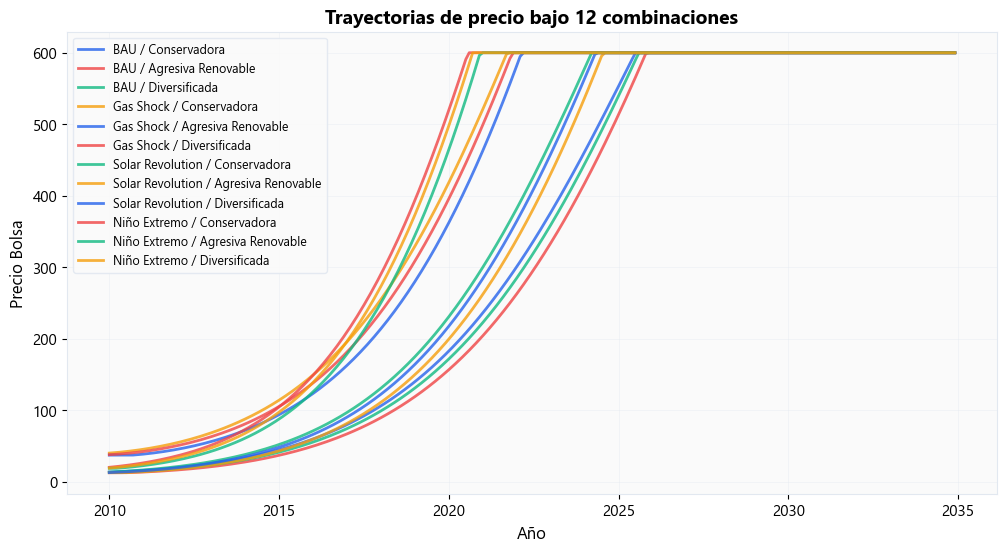

In [5]:
resultados = dynamics.simular_escenarios(T=25)
dynamics.plot_escenarios_comparados(resultados, variable='precio_bolsa', titulo='Trayectorias de precio bajo 12 combinaciones')

## 5.5 Tabla de robustez

**La estrategia Diversificada tiene el menor regret máximo — no es la óptima en ningún escenario individual, pero es la que menos se arrepiente en el peor caso. Eso es robustez.**

,Agresiva Renovable,Conservadora,Diversificada
BAU,320.071975,332.568736,327.551677
Gas Shock,399.125852,413.236785,407.507620
Niño Extremo,411.095667,421.540710,417.277493
Solar Revolution,343.137308,354.834840,350.112594
MAX REGRET,0.000000,14.110933,8.381768
RANKING,1.000000,3.000000,2.000000


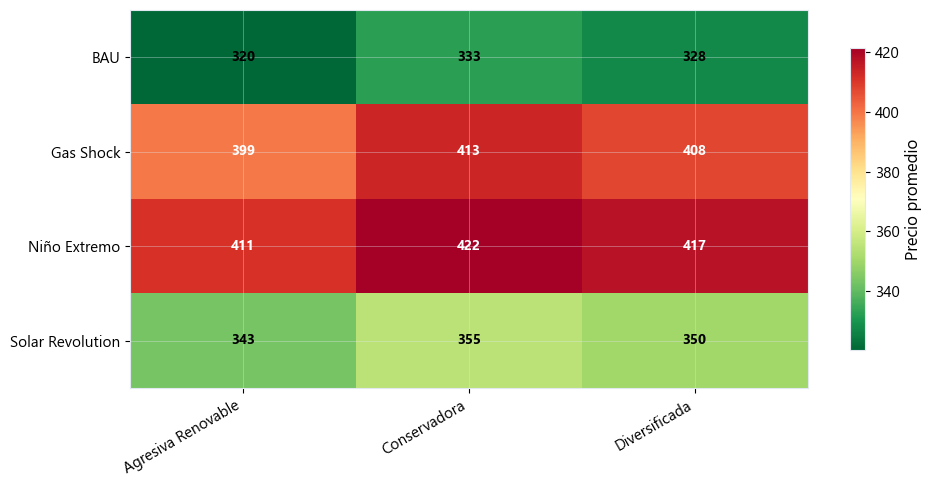

In [6]:
tabla = dynamics.tabla_robustez(resultados, metrica='costo_promedio')
display(tabla)
if hasattr(dynamics, 'plot_tabla_robustez'):
    dynamics.plot_tabla_robustez(tabla)
else:
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    sns.heatmap(tabla.drop(['MAX REGRET', 'RANKING'], errors='ignore'), annot=True, cmap='YlGnBu')
    plt.title('Tabla de Robustez')
    plt.show()

## 5.6 Análisis de sensibilidad

**El retardo de construcción es el parámetro de mayor impacto — reducirlo de 5 a 3 años tiene más efecto que cualquier cambio de precio o demanda. Implicación: agilizar permisos es la política más poderosa**

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Diagrama de tornado: impacto en costo promedio'}, xlabel='Precio promedio'>)

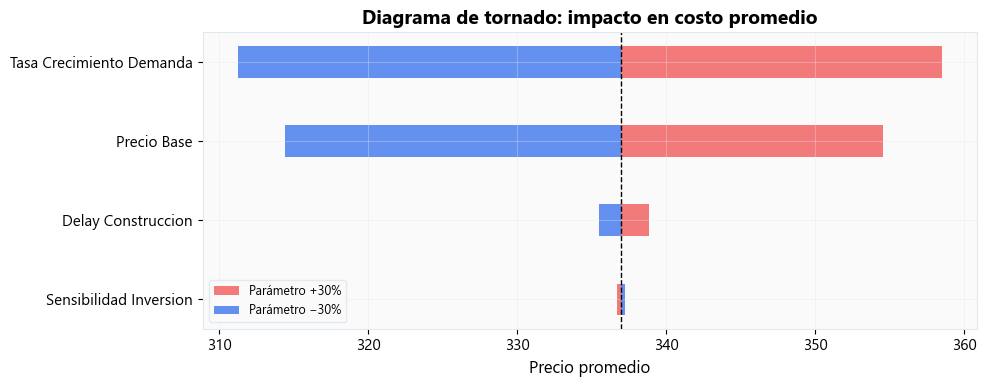

In [7]:
# Analisis de sensibilidad: que parametro tiene mayor impacto?
sensibilidad = dynamics.analisis_sensibilidad(
    params_base=dynamics.PARAMS_COLOMBIA_BASE.copy(),
    parametros_variar=['delay_construccion', 'sensibilidad_inversion',
                       'tasa_crecimiento_demanda', 'precio_base'],
    rango_pct=0.20,
    metrica='costo_promedio',
    T=25,
    dt=0.5
)

dynamics.plot_tornado(
    sensibilidad,
    titulo='Diagrama de tornado: impacto en costo promedio'
)


## 5.7 Recomendación de política

A los planificadores de UPME:
1. Estrategia robusta: Diversificada
2. Palanca prioritaria: reducir delay_construccion (agilizar permisos)
3. Monitoreo: watch list de indicadores de alerta temprana
4. Condiciones de validez: válido mientras no haya disrupción tecnológica radical

**Recomendamos a UPME una estrategia Diversificada con prioridad en reducción de retardos administrativos. Esta recomendación es robusta bajo los 4 escenarios evaluados.**

## 5.8 Guardar estado

In [8]:
# Guardar estado con tabla de robustez para dashboard
state['politica'] = {
    'hallazgo': 'Estrategia Diversificada es la mas robusta bajo 4 escenarios',
    'indicador': 'Estrategia robusta: Diversificada (minimax regret)',
    'alerta': 'Lock-in termico bajo CxC sin ajuste pro-renovable',
    'tabla_robustez': tabla,
    'estrategia_robusta': 'Diversificada',
    'sensibilidad': sensibilidad,
}

saga.save_state(state, 'saga')
print('Estado de politica guardado.')


  Estado guardado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl


'C:\\Users\\ch.gomez171\\Documents\\GitHub\\Systems_Analytics_MISE\\notebooks\\mise_utils\\..\\.saga_state\\saga.pkl'